Generating pitch deck visualizations...


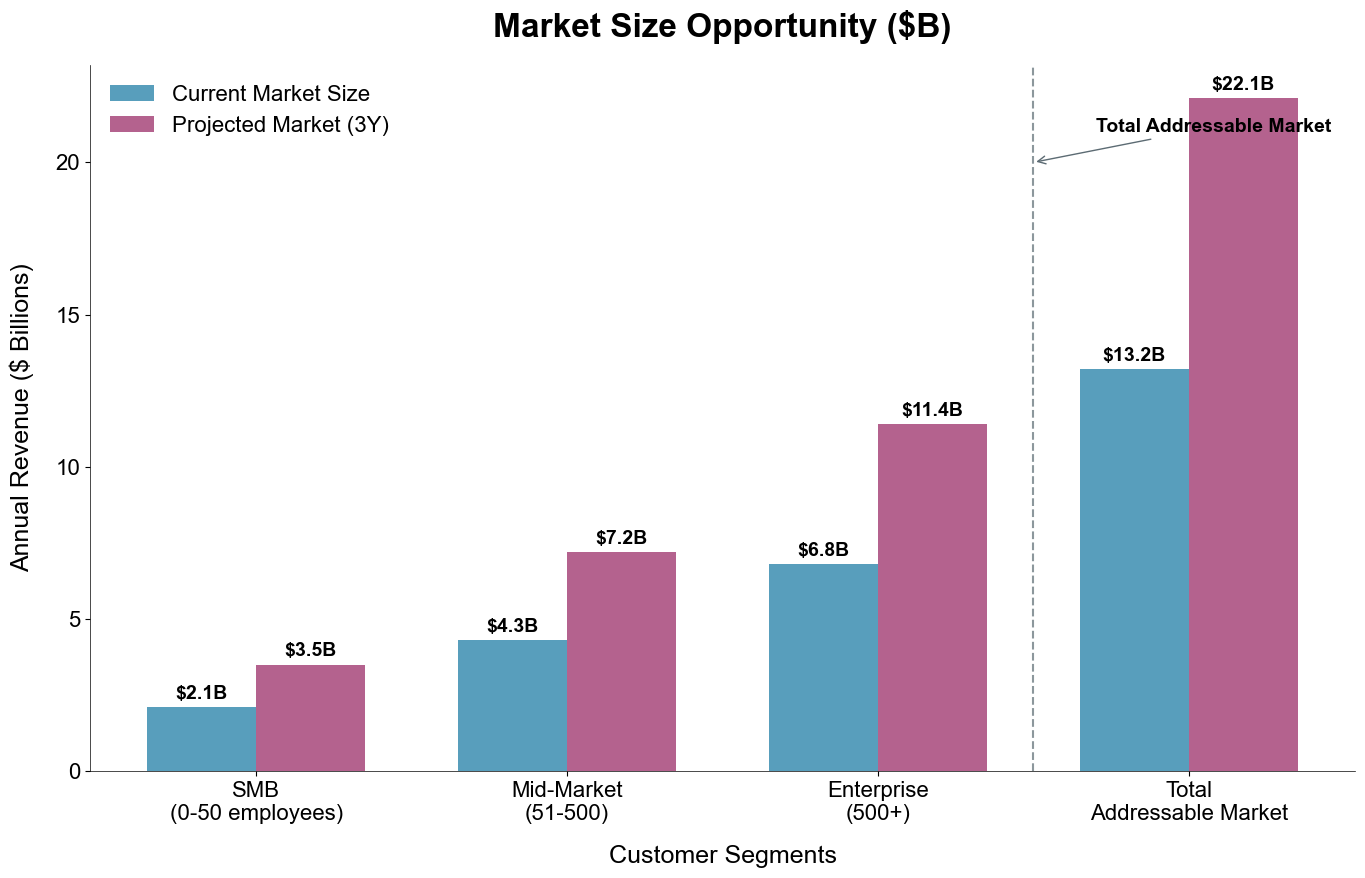

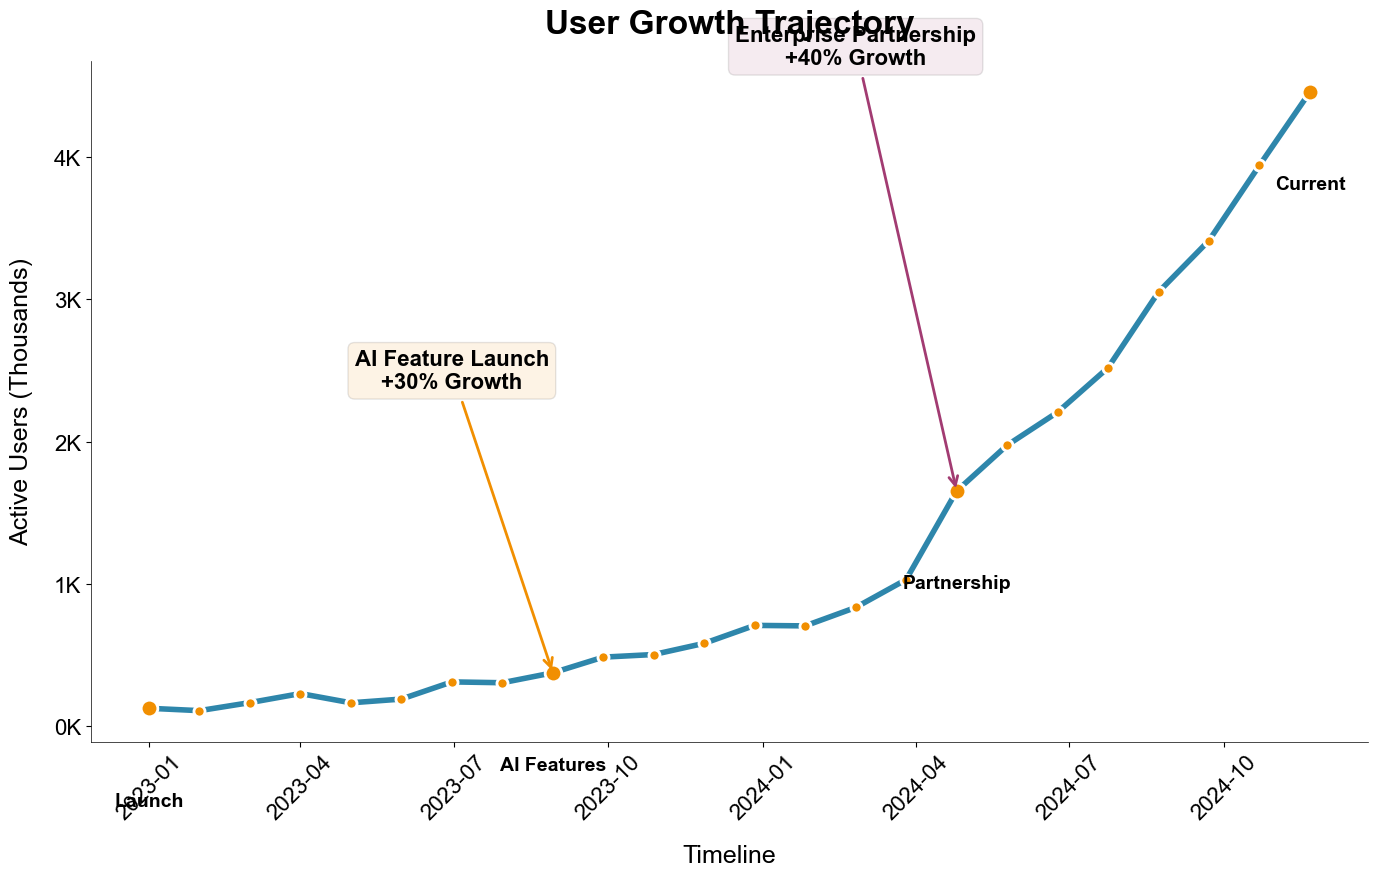

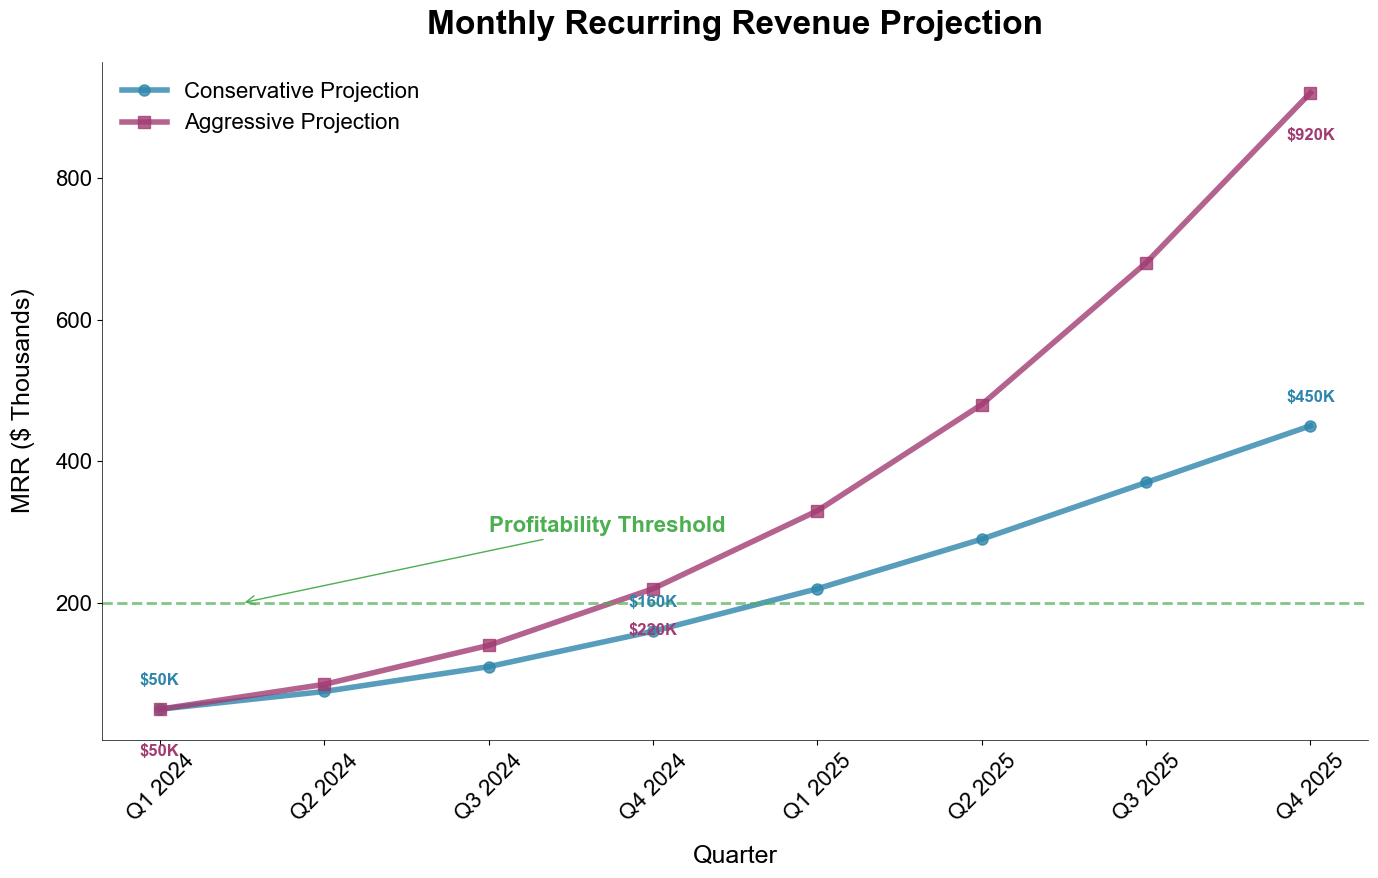

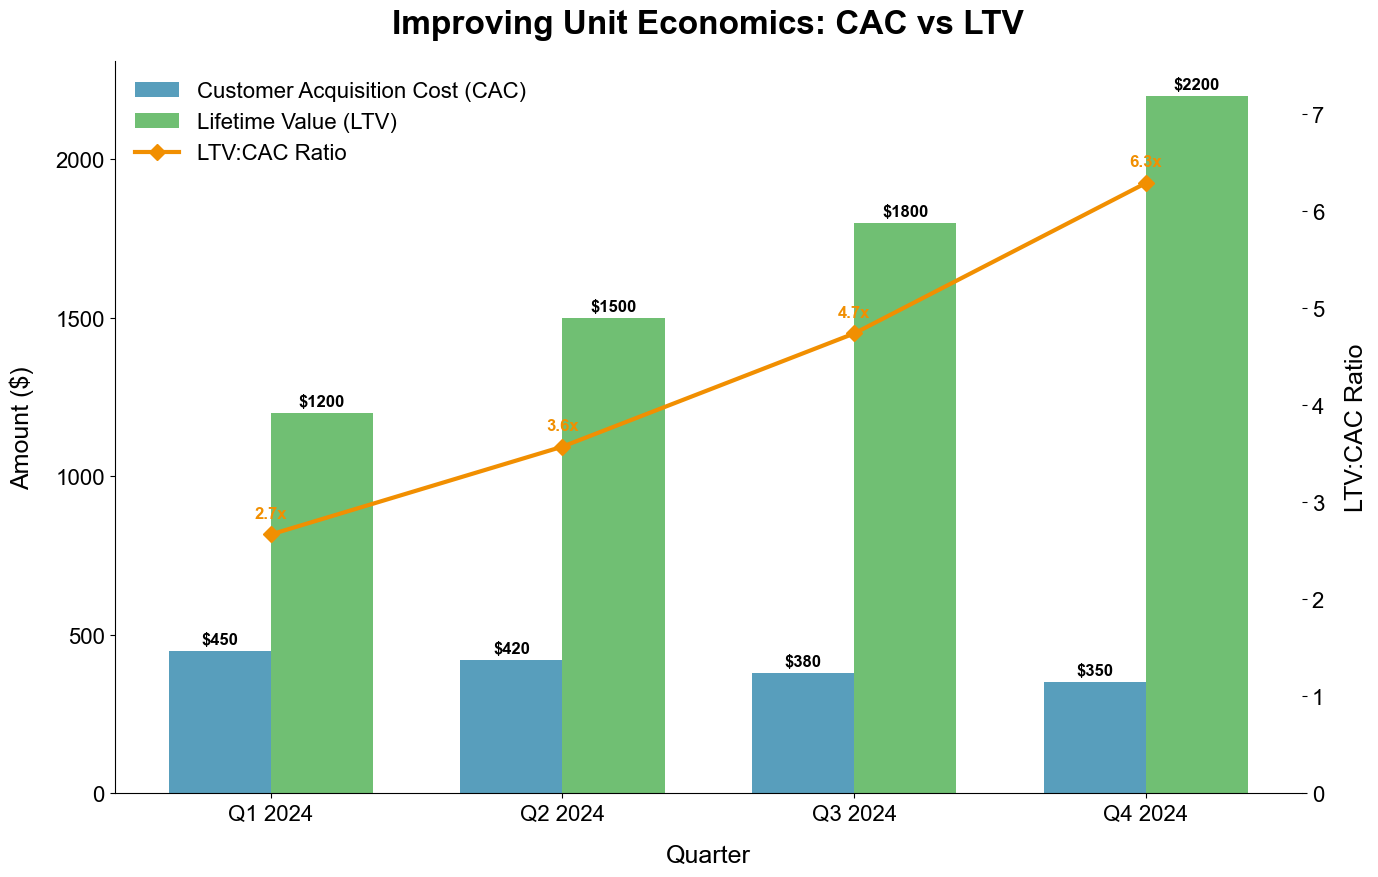

All charts generated successfully!
Files created:
- market_size_opportunity.png
- user_growth_trajectory.png
- mrr_projection.png
- cac_ltv_economics.png


In [1]:
# Pitch_Deck_Visuals.ipynb

# Setup & Prerequisites
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Set global style parameters for all charts
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Company brand colors (example - replace with actual brand colors)
BRAND_COLORS = {
    'primary': '#2E86AB',    # Deep blue
    'secondary': '#A23B72',  # Berry
    'accent': '#F18F01',     # Orange
    'neutral': '#5C6B73',    # Gray
    'success': '#4CAF50'     # Green
}

def setup_plot_style(ax, title, xlabel, ylabel):
    """Apply consistent styling to plots"""
    ax.set_title(title, fontsize=24, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=18, fontweight='normal', labelpad=15)
    ax.set_ylabel(ylabel, fontsize=18, fontweight='normal', labelpad=15)
    
    # Remove chart clutter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    # Remove grid lines for cleaner look
    ax.grid(False)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    return ax

# Core Execution: Create presentation-ready charts

# 1. Market Size Bar Chart
def create_market_size_chart():
    """Create a clean bar chart showing market size opportunity"""
    
    # Sample market data - replace with actual data
    segments = ['SMB\n(0-50 employees)', 'Mid-Market\n(51-500)', 'Enterprise\n(500+)', 'Total\nAddressable Market']
    current_revenue = [2.1, 4.3, 6.8, 13.2]  # $Billions
    projected_growth = [3.5, 7.2, 11.4, 22.1]  # $Billions in 3 years
    
    fig, ax = plt.subplots(figsize=(14, 9))
    
    x = np.arange(len(segments))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, current_revenue, width, 
                   label='Current Market Size', 
                   color=BRAND_COLORS['primary'],
                   alpha=0.8)
    
    bars2 = ax.bar(x + width/2, projected_growth, width, 
                   label='Projected Market (3Y)', 
                   color=BRAND_COLORS['secondary'],
                   alpha=0.8)
    
    ax = setup_plot_style(ax, 
                         'Market Size Opportunity ($B)', 
                         'Customer Segments', 
                         'Annual Revenue ($ Billions)')
    
    ax.set_xticks(x)
    ax.set_xticklabels(segments)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'${height}B',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),  # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=14, fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'${height}B',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=14, fontweight='bold')
    
    # Add legend
    ax.legend(frameon=False, fontsize=16, loc='upper left')
    
    # Highlight total addressable market
    ax.axvline(x=2.5, color=BRAND_COLORS['neutral'], linestyle='--', alpha=0.7)
    ax.annotate('Total Addressable Market', 
                xy=(2.5, 20), xytext=(2.7, 21),
                arrowprops=dict(arrowstyle='->', color=BRAND_COLORS['neutral']),
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('market_size_opportunity.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()

# 2. Simulated User Growth Line Chart
def create_user_growth_chart():
    """Create a clean line chart showing user growth with key milestones"""
    
    # Generate sample growth data - replace with actual data
    months = 24
    dates = [datetime(2023, 1, 1) + timedelta(days=30*i) for i in range(months)]
    
    # Simulated growth with acceleration points
    base_growth = np.array([100 * (1.15)**i for i in range(months)])
    # Add acceleration after key features
    accelerated_growth = base_growth.copy()
    accelerated_growth[8:] = accelerated_growth[8:] * 1.3  # Feature launch month 8
    accelerated_growth[16:] = accelerated_growth[16:] * 1.4  # Partnership month 16
    
    # Add some noise to make it realistic
    np.random.seed(42)
    noise = np.random.normal(0, 50, months)
    users = np.maximum(accelerated_growth + noise, 0)
    
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Plot growth line
    ax.plot(dates, users, 
            color=BRAND_COLORS['primary'], 
            linewidth=4,
            marker='o',
            markersize=8,
            markerfacecolor=BRAND_COLORS['accent'],
            markeredgecolor='white',
            markeredgewidth=2)
    
    ax = setup_plot_style(ax,
                         'User Growth Trajectory',
                         'Timeline',
                         'Active Users (Thousands)')
    
    # Format y-axis to show K for thousands
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    # Highlight key inflection points with annotations
    # Feature launch point
    ax.annotate('AI Feature Launch\n+30% Growth', 
                xy=(dates[8], users[8]), 
                xytext=(dates[6], users[8] + 2000),
                arrowprops=dict(arrowstyle='->', 
                              color=BRAND_COLORS['accent'],
                              lw=2),
                fontsize=16,
                fontweight='bold',
                ha='center',
                bbox=dict(boxstyle="round,pad=0.3", 
                         facecolor=BRAND_COLORS['accent'], 
                         alpha=0.1))
    
    # Partnership point
    ax.annotate('Enterprise Partnership\n+40% Growth', 
                xy=(dates[16], users[16]), 
                xytext=(dates[14], users[16] + 3000),
                arrowprops=dict(arrowstyle='->', 
                              color=BRAND_COLORS['secondary'],
                              lw=2),
                fontsize=16,
                fontweight='bold',
                ha='center',
                bbox=dict(boxstyle="round,pad=0.3", 
                         facecolor=BRAND_COLORS['secondary'], 
                         alpha=0.1))
    
    # Add milestone markers
    milestone_dates = [dates[0], dates[8], dates[16], dates[-1]]
    milestone_users = [users[0], users[8], users[16], users[-1]]
    milestone_labels = ['Launch', 'AI Features', 'Partnership', 'Current']
    
    for date, user_count, label in zip(milestone_dates, milestone_users, milestone_labels):
        ax.plot(date, user_count, 'o', 
               markersize=12,
               markerfacecolor=BRAND_COLORS['accent'],
               markeredgecolor='white',
               markeredgewidth=2)
        ax.annotate(label, 
                   xy=(date, user_count),
                   xytext=(0, -60),
                   textcoords="offset points",
                   ha='center', va='top',
                   fontsize=14,
                   fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('user_growth_trajectory.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

# 3. Projected MRR Line Chart
def create_mrr_projection_chart():
    """Create a clean line chart showing MRR projections"""
    
    # Sample MRR data - replace with actual projections
    quarters = ['Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024', 
                'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']
    
    # Conservative projection
    conservative_mrr = [50, 75, 110, 160, 220, 290, 370, 450]  # $Thousands
    
    # Aggressive projection
    aggressive_mrr = [50, 85, 140, 220, 330, 480, 680, 920]  # $Thousands
    
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Plot both projections
    ax.plot(quarters, conservative_mrr, 
            color=BRAND_COLORS['primary'],
            linewidth=4,
            marker='o',
            markersize=8,
            label='Conservative Projection',
            alpha=0.8)
    
    ax.plot(quarters, aggressive_mrr,
            color=BRAND_COLORS['secondary'],
            linewidth=4,
            marker='s',
            markersize=8,
            label='Aggressive Projection',
            alpha=0.8)
    
    ax = setup_plot_style(ax,
                         'Monthly Recurring Revenue Projection',
                         'Quarter',
                         'MRR ($ Thousands)')
    
    # Add value annotations for key points
    for i, (cons, agg) in enumerate(zip(conservative_mrr, aggressive_mrr)):
        if i in [0, 3, 7]:  # Annotate first, year-end, and final points
            ax.annotate(f'${cons}K', 
                       xy=(i, cons),
                       xytext=(0, 15),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=12,
                       fontweight='bold',
                       color=BRAND_COLORS['primary'])
            
            ax.annotate(f'${agg}K', 
                       xy=(i, agg),
                       xytext=(0, -25),
                       textcoords="offset points",
                       ha='center', va='top',
                       fontsize=12,
                       fontweight='bold',
                       color=BRAND_COLORS['secondary'])
    
    # Highlight profitability milestone
    profitability_threshold = 200  # $200K MRR for profitability
    ax.axhline(y=profitability_threshold, color=BRAND_COLORS['success'], 
               linestyle='--', alpha=0.7, linewidth=2)
    
    ax.annotate('Profitability Threshold', 
                xy=(0.5, profitability_threshold), 
                xytext=(2, profitability_threshold + 100),
                arrowprops=dict(arrowstyle='->', 
                              color=BRAND_COLORS['success']),
                fontsize=16,
                fontweight='bold',
                color=BRAND_COLORS['success'])
    
    # Add legend
    ax.legend(frameon=False, fontsize=16, loc='upper left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('mrr_projection.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

# 4. Customer Acquisition Cost vs Lifetime Value
def create_cac_ltv_chart():
    """Create a bar chart comparing CAC and LTV"""
    
    quarters = ['Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024']
    cac = [450, 420, 380, 350]  # Customer Acquisition Cost
    ltv = [1200, 1500, 1800, 2200]  # Lifetime Value
    
    fig, ax = plt.subplots(figsize=(14, 9))
    
    x = np.arange(len(quarters))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cac, width,
                   label='Customer Acquisition Cost (CAC)',
                   color=BRAND_COLORS['primary'],
                   alpha=0.8)
    
    bars2 = ax.bar(x + width/2, ltv, width,
                   label='Lifetime Value (LTV)',
                   color=BRAND_COLORS['success'],
                   alpha=0.8)
    
    ax = setup_plot_style(ax,
                         'Improving Unit Economics: CAC vs LTV',
                         'Quarter',
                         'Amount ($)')
    
    ax.set_xticks(x)
    ax.set_xticklabels(quarters)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'${height}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=12,
                   fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'${height}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=12,
                   fontweight='bold')
    
    # Add LTV:CAC ratio line
    ratios = [ltv[i]/cac[i] for i in range(len(quarters))]
    ax2 = ax.twinx()
    ax2.plot(x, ratios, 
             color=BRAND_COLORS['accent'],
             linewidth=3,
             marker='D',
             markersize=8,
             label='LTV:CAC Ratio')
    
    ax2.set_ylabel('LTV:CAC Ratio', fontsize=18, fontweight='normal', labelpad=15)
    ax2.tick_params(axis='y', labelsize=16)
    ax2.set_ylim(0, max(ratios) * 1.2)
    
    # Add ratio value annotations
    for i, ratio in enumerate(ratios):
        ax2.annotate(f'{ratio:.1f}x',
                    xy=(i, ratio),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=12,
                    fontweight='bold',
                    color=BRAND_COLORS['accent'])
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, 
              frameon=False, fontsize=16, loc='upper left')
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('cac_ltv_economics.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

# Validation & Output: Generate all charts
print("Generating pitch deck visualizations...")

# Create all charts
create_market_size_chart()
create_user_growth_chart()
create_mrr_projection_chart()
create_cac_ltv_chart()

print("All charts generated successfully!")
print("Files created:")
print("- market_size_opportunity.png")
print("- user_growth_trajectory.png")
print("- mrr_projection.png")
print("- cac_ltv_economics.png")